> Zacharis Efstathios, Mathematician M.Sc. Statistics <br />
> Data Science Postgraduate Student <br />
> efs.zacharis@aueb.gr

# Multi-Modal Two-Tower Recommendation System

## Clone Entire Git Repository

In [4]:
import os

if not os.path.exists('msc-data-science-aueb'):
  !git clone https://github.com/StathZa/msc-data-science-aueb.git

%cd msc-data-science-aueb/recommender-systems/two-tower-retrieval

/content/msc-data-science-aueb/recommender-systems/two-tower-retrieval


## Publish changes on GIT

In [30]:
p = Path(os.getcwd()) / "evaluate_utils"
p.mkdir(parents=True, exist_ok=True)
!mv utils/recommend.py evaluate_utils/recommend.py
data_dir: str = Path(os.getcwd()) / "data" / "reviews" # metadata
data_dir=os.path.join(data_dir, '.ipynb_checkpoints')
data_dir
os.rmdir(data_dir)
ds_path = Path(os.getcwd()) / "utils" / "recommend.py"
ds_path.touch(mode=700, exist_ok=True)
model_path = Path(os.getcwd()) / "utils" / "evaluate.py"
model_path.touch(mode=700, exist_ok=True)

In [8]:
!git rm --cached msc-data-science-aueb
!rm -rf msc-data-science-aueb
!echo "msc-data-science-aueb/" >> .gitignore

from google.colab import userdata
token = userdata.get('github')

!git config --global user.name "StathZa"
!git config --global user.email "142407371+StathZa@users.noreply.github.com"

!git remote set-url origin https://{token}@github.com/StathZa/msc-data-science-aueb.git

!git rm --cached tokens.env
!echo "tokens.env" >> .gitignore
!echo "*.env" >> .gitignore
!git rm --cached -r data/
!echo "data/" >> .gitignore

!git add .
!git commit -m "Configurations added to data loader"
!git commit --amend -m "Used logger"
!git push --force

!find . -name "*.ipynb"
!cat .gitignore | grep -i ipynb
!ls -lh ./Recommender.ipynb
!git add -f Recommender.ipynb
!git commit -m "Add notebook"
!git push
!git diff Recommender.ipynb

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [19]:
from google.colab import userdata
token = userdata.get('github')

!git config --global user.name "StathZa"
!git config --global user.email "142407371+StathZa@users.noreply.github.com"

!git remote set-url origin https://{token}@github.com/StathZa/msc-data-science-aueb.git


!git add .
!git commit -m "Sample data added"
!git push

[main d9199ca] Sample data added
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 recommender-systems/two-tower-retrieval/data/metadata/review_metadata.parquet.gzip
 create mode 100644 recommender-systems/two-tower-retrieval/data/reviews/review_data.parquet.gzip
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 77.96 MiB | 17.87 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
remote: warning: See https://gh.io/lfs for more information.
remote: warning: File recommender-systems/two-tower-retrieval/data/metadata/review_metadata.parquet.gzip is 64.32 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB
remote: warning: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.
remote: This rep

## Program setup and dependencies installation

In [10]:
!bash setup/setup.sh

Installing packages for automatic library detection and project handling
Master script detected at: /content/msc-data-science-aueb/recommender-systems/two-tower-retrieval/setup
/content/msc-data-science-aueb/recommender-systems/two-tower-retrieval
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 81.1 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 56 packages in 1.25s
Prepared 9 packages in 804ms
Uninstalled 1 package in 23ms
Installed 9 packages in 239ms
 + asttokens==3.0.1
 + docopt==0.6.2
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==8.12.3
 + jedi==0.20.0
 + pipreqs==0.5.0
 + pure-eval==0.2.3
 + stack-data==0.6.3
 + yarg==0.1.9
/usr/local/lib/python3.12/dist-packages/docopt.py:165: SyntaxWarning: invalid escape sequence '\S'
  name = re.findall('(<\S*?>)', source)[0]
/usr/local/lib/python3.12/dist-packages/docopt.py:166: SyntaxWarning: invalid escape sequence '\['
  value = re.findall('\[default: (.*)\]', source, flags=re.I)
/usr/local/lib/python3.1

## Imports

In [7]:
# Import necessary functions and classes
from utils.libs import *
from utils.logger import Logger
from preprocess_utils.data_load_preprocess import *
from preprocess_utils.features import *
from preprocess_utils.split import train_val_test_split
from preprocess_utils.dataset import get_dataloader
from evaluate_utils.recommend import recommend_for_user
from model_utils.train import train_one_epoch
from evaluate_utils.evaluate import evaluate
from model_utils.model import TwoTowerModel, EMBED_DIM, CAT_EMB


# set seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Logger

In [11]:
try:
  logger = Logger().logger
  logger.info("Logger initialised succesfully!")
except Exception as e:
  logger.exception("Could not initialise logger for this program. Exiting...")

06-05-2026 11:06:13 INFO [1850941187.<module>:3]: Logger initialised succesfully!
INFO:recommender_system_logger:Logger initialised succesfully!


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f'Using device: {device}')

06-05-2026 11:06:14 INFO [4135095890.<module>:2]: Using device: cuda
INFO:recommender_system_logger:Using device: cuda


## Pre-processing

In [13]:
# Store token in a .env file
dot = Path(os.getcwd()) / "tokens.env"

if load_dotenv("tokens.env"):
  logger.info(f"Successfully retrieved {len(dict(dotenv_values("tokens.env")))} token(s) from hidden file")
  hf_access_token = os.environ["HFtoken"]
else:
  logger.info("Create .env file")
  dot.touch(mode=700, exist_ok=True)
  try:
    hf_access_token = userdata.get('HFtoken') # Get the HuugingFace token named HFToken in secrets
    logger.info(f"Get the personal HuggingFace token. If you do not have one and want to get a local copy of dataset please advice the source https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023")

    # write token to empty file
    with open("tokens.env", "w") as f:
      f.write(f"HFtoken={hf_access_token}")
  except Exception as e:
    logger.exception("Could not access personal HuggingFace token.")
    hf_access_token = None

06-05-2026 11:06:16 INFO [1099417545.<module>:5]: Successfully retrieved 1 token(s) from hidden file
INFO:recommender_system_logger:Successfully retrieved 1 token(s) from hidden file


In [29]:
# Create a local copy of reviews_params to modify it
logger.info("Loaded parameters")
local_reviews_params = reviews_params.copy()
local_metadata_params = metadata_params.copy()

# Add the token for authentication
local_reviews_params['token'] = hf_access_token
local_metadata_params['token'] = hf_access_token

# Load the dataset with authentication and no verification checks
logger.info("Fetching data from source")
reviews_df = fetch_review_data(parameters=local_reviews_params, logger=logger, max_rows=500_000)
metadata_df = fetch_review_metadata(parameters=local_metadata_params, logger=logger, max_rows=500_000)

logger.info(f'Reviews: {len(reviews_df)}')
print('Review columns:', reviews_df.columns.tolist())
logger.info(f'Items: {len(metadata_df)}')
print('Meta columns:', metadata_df.columns.tolist())

06-05-2026 11:18:21 INFO [491054581.<module>:2]: Loaded parameters
INFO:recommender_system_logger:Loaded parameters
06-05-2026 11:18:21 INFO [491054581.<module>:11]: Fetching data from source
INFO:recommender_system_logger:Fetching data from source
06-05-2026 11:18:21 INFO [data_load_preprocess.fetch_review_data:49]: Checking filesystem for the data
INFO:recommender_system_logger:Checking filesystem for the data
06-05-2026 11:18:21 WARNING [data_load_preprocess.fetch_review_data:53]: Creating data directory to persist the reviews and metadata content
06-05-2026 11:18:21 INFO [data_load_preprocess.fetch_review_data:55]: Data directory /content/msc-data-science-aueb/recommender-systems/two-tower-retrieval/data/reviews created. Downloading data from source
INFO:recommender_system_logger:Data directory /content/msc-data-science-aueb/recommender-systems/two-tower-retrieval/data/reviews created. Downloading data from source
06-05-2026 11:18:33 INFO [data_load_preprocess._stream_to_dataframe:

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Meta columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [30]:
result = prepare_training_data(reviews_df, metadata_df, logger=logger)

df = result['df']
user2idx = result['user2idx']
item2idx = result['item2idx']
cat_vocab = result['cat_vocab']
items_df = result['items_df']

logger.info(f"Final: {len(df):,} interactions, {len(user2idx):,} users, {len(item2idx):,} items")

06-05-2026 11:26:26 INFO [data_load_preprocess.prepare_training_data:168]: 
Preprocessing data
INFO:recommender_system_logger:
Preprocessing data
06-05-2026 11:26:26 INFO [data_load_preprocess.prepare_training_data:169]: ==================================================
INFO:recommender_system_logger:==================================================
06-05-2026 11:26:26 INFO [data_load_preprocess.prepare_training_data:170]: PART 1 - CLEANUP
INFO:recommender_system_logger:PART 1 - CLEANUP
06-05-2026 11:26:26 INFO [data_load_preprocess.prepare_training_data:171]: ==================================================
INFO:recommender_system_logger:==================================================
06-05-2026 11:26:26 INFO [data_load_preprocess.prepare_training_data:176]: Trimming reviews with rating >= 4 as positive interactions.
INFO:recommender_system_logger:Trimming reviews with rating >= 4 as positive interactions.
06-05-2026 11:26:27 INFO [data_load_preprocess.prepare_training_data:184

In [31]:
# Build feature tensors
text_emb = build_text_embeddings(items_df, device, logger=logger)
item_num = build_numerical_features(items_df, item2idx, logger=logger)
item_cat = build_categorical_features(items_df, item2idx, cat_vocab, logger=logger)

item_cat_d = item_cat.to(device)
item_num_d = item_num.to(device)
text_emb_d = text_emb.to(device)

06-05-2026 11:28:19 INFO [features.build_text_embeddings:8]: Encode item features
INFO:recommender_system_logger:Encode item features


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

06-05-2026 11:28:59 INFO [features.build_text_embeddings:17]: Text embedding shape: torch.Size([22407, 384])
INFO:recommender_system_logger:Text embedding shape: torch.Size([22407, 384])
06-05-2026 11:28:59 INFO [features.build_numerical_features:26]: Normalise numerical features for 2 Tower ingestion
INFO:recommender_system_logger:Normalise numerical features for 2 Tower ingestion
06-05-2026 11:28:59 INFO [features.build_numerical_features:45]: Numerical features shape: torch.Size([22407, 2])
INFO:recommender_system_logger:Numerical features shape: torch.Size([22407, 2])
06-05-2026 11:28:59 INFO [features.build_categorical_features:61]: Categorical features shape: torch.Size([22407, 2])
INFO:recommender_system_logger:Categorical features shape: torch.Size([22407, 2])


In [32]:
train_df, val_df, test_df, user_pos_items = train_val_test_split(df, user2idx, item2idx, logger=logger)

06-05-2026 11:29:01 INFO [split.train_val_test_split:28]: Train: 103,183  |  Val: 18,122  |  Test: 18,122
INFO:recommender_system_logger:Train: 103,183  |  Val: 18,122  |  Test: 18,122


In [ ]:
from model_utils.tuning import hyperparameter_search

results = hyperparameter_search(
    train_df, val_df, user2idx, item2idx, cat_vocab,
    user_pos_items, item_cat_d, item_num_d, text_emb_d,
    device, logger=logger
)

results_df = pd.DataFrame(results).sort_values('best_NDCG@10', ascending=False)
print(results_df.to_string(index=False))

# Extract best params
best = results_df.iloc[0]
BEST_EMBED_DIM = int(best.embed_dim)
BEST_LR = best.lr
BEST_BATCH_SIZE = int(best.batch_size)
logger.info(f"Best: embed_dim={BEST_EMBED_DIM}, lr={BEST_LR}, batch_size={BEST_BATCH_SIZE}")

06-05-2026 11:29:01 INFO [tuning.hyperparameter_search:22]: Running grid search: 18 combinations
INFO:recommender_system_logger:Running grid search: 18 combinations
06-05-2026 11:29:01 INFO [tuning.hyperparameter_search:26]: 
[1/18] {'embed_dim': 32, 'lr': 0.01, 'batch_size': 512}
INFO:recommender_system_logger:
[1/18] {'embed_dim': 32, 'lr': 0.01, 'batch_size': 512}


In [10]:
# train_loader = get_dataloader(train_df, user2idx, item2idx, user_pos_items,
#                                len(item2idx), batch_size=1024)
# logger.info(f"Train batches per epoch: {len(train_loader)}")

# cat_vocab_sizes = [len(cat_vocab['main_category']), len(cat_vocab['store'])]
# TEXT_DIM = text_emb.shape[1]

# model = TwoTowerModel(
#     num_users=len(user2idx),
#     cat_vocab_sizes=cat_vocab_sizes,
#     cat_emb_dim=CAT_EMB,
#     num_numeric=2,
#     text_dim=TEXT_DIM,
#     embed_dim=EMBED_DIM
# ).to(device)

# logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

05-05-2026 13:05:38 INFO [1589550250.<module>:15]: Model parameters: 511,552
INFO:recommender_system_logger:Model parameters: 511,552


In [24]:
train_loader = get_dataloader(train_df, user2idx, item2idx, user_pos_items,
                               len(item2idx), batch_size=BEST_BATCH_SIZE)

cat_vocab_sizes = [len(cat_vocab['main_category']), len(cat_vocab['store'])]

model = TwoTowerModel(
    num_users=len(user2idx),
    cat_vocab_sizes=cat_vocab_sizes,
    cat_emb_dim=16,
    num_numeric=2,
    text_dim=text_emb.shape[1],
    embed_dim=BEST_EMBED_DIM
).to(device)

EPOCHS = 50
PATIENCE = 7
optimizer = torch.optim.Adam(model.parameters(), lr=BEST_LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

losses = []
val_results = []
best_ndcg = 0.0
patience_counter = 0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimizer,
                           item_cat_d, item_num_d, text_emb_d, device)
    scheduler.step()
    losses.append(loss)

    val_res = evaluate(model, val_df, user2idx, item2idx, user_pos_items,
                       item_cat_d, item_num_d, text_emb_d, device, logger=None)
    val_results.append((epoch, val_res))

    logger.info(f"Epoch {epoch:02d}/{EPOCHS} — Loss: {loss:.4f} | "
                f"Val HR@10: {val_res['HR@10']:.4f} | Val NDCG@10: {val_res['NDCG@10']:.4f}")

    if val_res['NDCG@10'] > best_ndcg:
        best_ndcg = val_res['NDCG@10']
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            logger.info(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

model.load_state_dict(torch.load('best_model.pt'))
logger.info(f"\nBest model from epoch {best_epoch}")
logger.info("Final evaluation on TEST set:")
test_results = evaluate(model, test_df, user2idx, item2idx, user_pos_items,
                        item_cat_d, item_num_d, text_emb_d, device, logger=logger)

06-05-2026 11:15:08 INFO [3612284294.<module>:36]: Epoch 01/50 — Loss: 0.6930 | Val HR@10: 0.1175 | Val NDCG@10: 0.0590
INFO:recommender_system_logger:Epoch 01/50 — Loss: 0.6930 | Val HR@10: 0.1175 | Val NDCG@10: 0.0590
06-05-2026 11:15:08 INFO [3612284294.<module>:36]: Epoch 02/50 — Loss: 0.6800 | Val HR@10: 0.1544 | Val NDCG@10: 0.0798
INFO:recommender_system_logger:Epoch 02/50 — Loss: 0.6800 | Val HR@10: 0.1544 | Val NDCG@10: 0.0798
06-05-2026 11:15:09 INFO [3612284294.<module>:36]: Epoch 03/50 — Loss: 0.6496 | Val HR@10: 0.1498 | Val NDCG@10: 0.0799
INFO:recommender_system_logger:Epoch 03/50 — Loss: 0.6496 | Val HR@10: 0.1498 | Val NDCG@10: 0.0799
06-05-2026 11:15:10 INFO [3612284294.<module>:36]: Epoch 04/50 — Loss: 0.6122 | Val HR@10: 0.1521 | Val NDCG@10: 0.0766
INFO:recommender_system_logger:Epoch 04/50 — Loss: 0.6122 | Val HR@10: 0.1521 | Val NDCG@10: 0.0766
06-05-2026 11:15:10 INFO [3612284294.<module>:36]: Epoch 05/50 — Loss: 0.5842 | Val HR@10: 0.1567 | Val NDCG@10: 0.0897


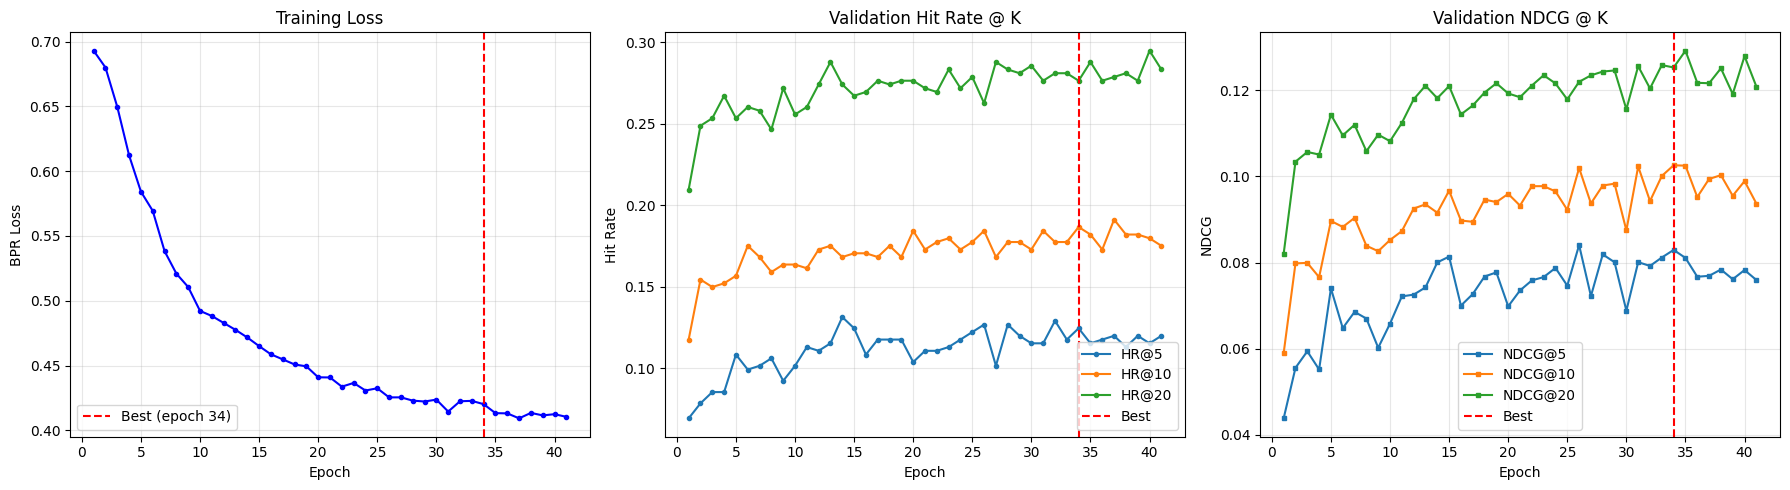


Test Results (best epoch 34):
 Metric  Value
   HR@5 0.0829
 NDCG@5 0.0527
  HR@10 0.1406
NDCG@10 0.0706
  HR@20 0.2512
NDCG@20 0.0982


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, len(losses)+1), losses, 'b-o', markersize=3)
axes[0].axvline(x=best_epoch, color='r', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BPR Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

epochs = [e for e, _ in val_results]
for k in [5, 10, 20]:
    vals = [r[f'HR@{k}'] for _, r in val_results]
    axes[1].plot(epochs, vals, '-o', label=f'HR@{k}', markersize=3)
axes[1].axvline(x=best_epoch, color='r', linestyle='--', label='Best')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Hit Rate')
axes[1].set_title('Validation Hit Rate @ K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for k in [5, 10, 20]:
    vals = [r[f'NDCG@{k}'] for _, r in val_results]
    axes[2].plot(epochs, vals, '-s', label=f'NDCG@{k}', markersize=3)
axes[2].axvline(x=best_epoch, color='r', linestyle='--', label='Best')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('NDCG')
axes[2].set_title('Validation NDCG @ K')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Results table
metrics_df = pd.DataFrame([
    {'Metric': k, 'Value': f'{v:.4f}'} for k, v in test_results.items()
])
print(f"\nTest Results (best epoch {best_epoch}):")
print(metrics_df.to_string(index=False))

In [26]:
sample_users = test_df['user_id'].drop_duplicates().sample(3, random_state=42).tolist()

for uid in sample_users:
    actual = df[df['user_id'] == uid][['item_id', 'title', 'main_category']].head(5)
    logger.info(f"\n{'='*60}")
    logger.info(f"User: {uid}")
    logger.info("Previously liked:")
    for _, r in actual.iterrows():
        logger.info(f"  - {r['title'][:60]} [{r['main_category']}]")

    recs = recommend_for_user(model, uid, user2idx, item2idx, items_df,
                              item_cat_d, item_num_d, text_emb_d, device,
                              user_pos_items=user_pos_items, k=5)
    logger.info("Recommended:")
    for r in recs:
        logger.info(f"  - {r['title']} [{r['category']}] ${r['price']:.2f} (score: {r['score']:.3f})")

06-05-2026 11:15:32 INFO [2852077393.<module>:5]: 
INFO:recommender_system_logger:
06-05-2026 11:15:32 INFO [2852077393.<module>:6]: User: AGN77Y4XMITXHDOOVYTIS5ARTU2Q
INFO:recommender_system_logger:User: AGN77Y4XMITXHDOOVYTIS5ARTU2Q
06-05-2026 11:15:32 INFO [2852077393.<module>:7]: Previously liked:
INFO:recommender_system_logger:Previously liked:
06-05-2026 11:15:32 INFO [2852077393.<module>:9]:   - Fintie Stand Case for 6" Kindle Paperwhite (Fits 10th Genera [Computers]
INFO:recommender_system_logger:  - Fintie Stand Case for 6" Kindle Paperwhite (Fits 10th Genera [Computers]
06-05-2026 11:15:32 INFO [2852077393.<module>:9]:   - Fintie Slimshell Case for 6" Kindle Paperwhite 2012-2017 (Mo [Amazon Devices]
INFO:recommender_system_logger:  - Fintie Slimshell Case for 6" Kindle Paperwhite 2012-2017 (Mo [Amazon Devices]
06-05-2026 11:15:32 INFO [2852077393.<module>:9]:   - Tenergy 9V Battery Rechargeable 250mAh 2PCS NiMH Square Batt [All Electronics]
INFO:recommender_system_logger:  - T